# karuppiah2025 — Karuppiah et al. (2025) TDA for Understanding DL

Direct VR persistent homology on Euclidean activation distances, **per layer**, of a trained CNN.  Diagram statistics track layer depth.


## What the paper does

A survey/methodology article framing TDA as a lens on deep learning.  The concrete recipe: take each layer's activation matrix as a point cloud (one point per input sample), compute **Euclidean** distances between the activation vectors, and run Vietoris–Rips persistent homology on that distance matrix — one diagram per layer.

**Methodology:** per-layer activations → Euclidean distance → VR PH (`H0`,`H1`) → persistence-diagram statistics per layer.

**Expected result:** the diagram summaries (number of `H1` loops, persistence entropy, total persistence) **vary systematically with depth** — a trained network progressively simplifies the topology of its representations, so later layers have fewer, shorter-lived generators.


## Dataset & model in the paper

- **Venue:** IEEE ICTBIG 2025
- **Datasets used:** Standard image classification benchmarks (the paper is broadly survey-style).
- **Models used:** Generic CNNs / MLPs as illustrative examples.
- **Headline result to aim for:** Persistence-diagram statistics correlate with layer depth and learned representation quality.
- **Reference code:** no public repo found in web search — check paper supplementary materials.

To reproduce paper numbers, replace the synthetic-data cell below with the real model snapshot / activations / trajectory.  Everything else in the notebook stays the same.


**This notebook runs on real data.**  A small CNN is trained briefly on the local CIFAR-10 cache and its per-layer activations are analysed.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch
from tanc import TDAPipeline
from paper_reproduce._torch_setup import (
    load_mnist, load_fashion_mnist, load_cifar10, load_cifar100,
    SmallMLP, SmallCNN, CNN_FCN, CNN_FCN2, VGGLike, train_briefly, extract_snapshot, pick_device,
)
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'


## 1. Train a small CNN on CIFAR-10


In [2]:
X_tr, y_tr = load_cifar10('train', n_samples=2000)
X_te, y_te = load_cifar10('test',  n_samples=400)
model = CNN_FCN(in_channels=3, num_classes=10, width=16, feat=64, hidden=32)
train_briefly(model, X_tr, y_tr, X_te, y_te, epochs=4,
              aspects=['activations'], device=DEVICE, verbose=False)
print('trained.')


paper_reproduce/_torch_setup.py:525: UserWarning: Model 'Sequential' has both fully-connected (linear / SoRO) and conv layers. Defaulting to the fully-connected layers. Pass layer_selection='all_linear', 'all_conv', 'soro', 'linear_and_conv', 'all', or a list of names/indices to suppress this warning.
  extractor = TrainingExtractor(


trained.


## 2. Per-layer VR persistent homology — model-first

`fit_model(..., representation='activations')` extracts each layer's activation matrix on a 64-sample batch and runs VR PH per layer, returning one `TopoResult` per layer.


In [3]:
pipe = TDAPipeline.from_paper("karuppiah2025")
results = pipe.fit_model(model, X_te[:64],
                         representation='activations',
                         layer_selection='linear_and_conv')
for i, r in enumerate(results):
    print(f'  layer {i}: H0={len(r.diagram(0))} bars, H1={len(r.diagram(1))} loops')


  layer 0: H0=64 bars, H1=19 loops
  layer 1: H0=64 bars, H1=15 loops
  layer 2: H0=64 bars, H1=8 loops
  layer 3: H0=64 bars, H1=3 loops


## 3. Diagram statistics vs layer depth

The paper's headline: topological summaries change monotonically with depth as the representation is simplified.


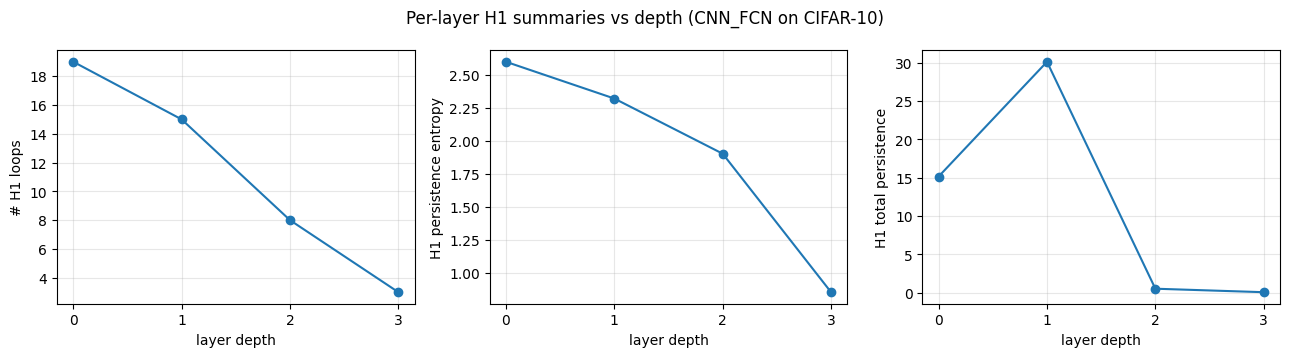

In [4]:
layers = list(range(len(results)))
n_h1     = [len(r.diagram(1)) for r in results]
entropy  = [r.statistics.get('H1_persistence_entropy', 0.0) for r in results]
totpers  = [r.statistics.get('H1_total_persistence', 0.0) for r in results]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, y, lab in zip(axes, [n_h1, entropy, totpers],
                      ['# H1 loops', 'H1 persistence entropy', 'H1 total persistence']):
    ax.plot(layers, y, 'o-'); ax.set_xlabel('layer depth'); ax.set_ylabel(lab)
    ax.set_xticks(layers); ax.grid(alpha=0.3)
fig.suptitle('Per-layer H1 summaries vs depth (CNN_FCN on CIFAR-10)')
fig.tight_layout(); plt.show()


## 4. Per-layer persistence diagrams


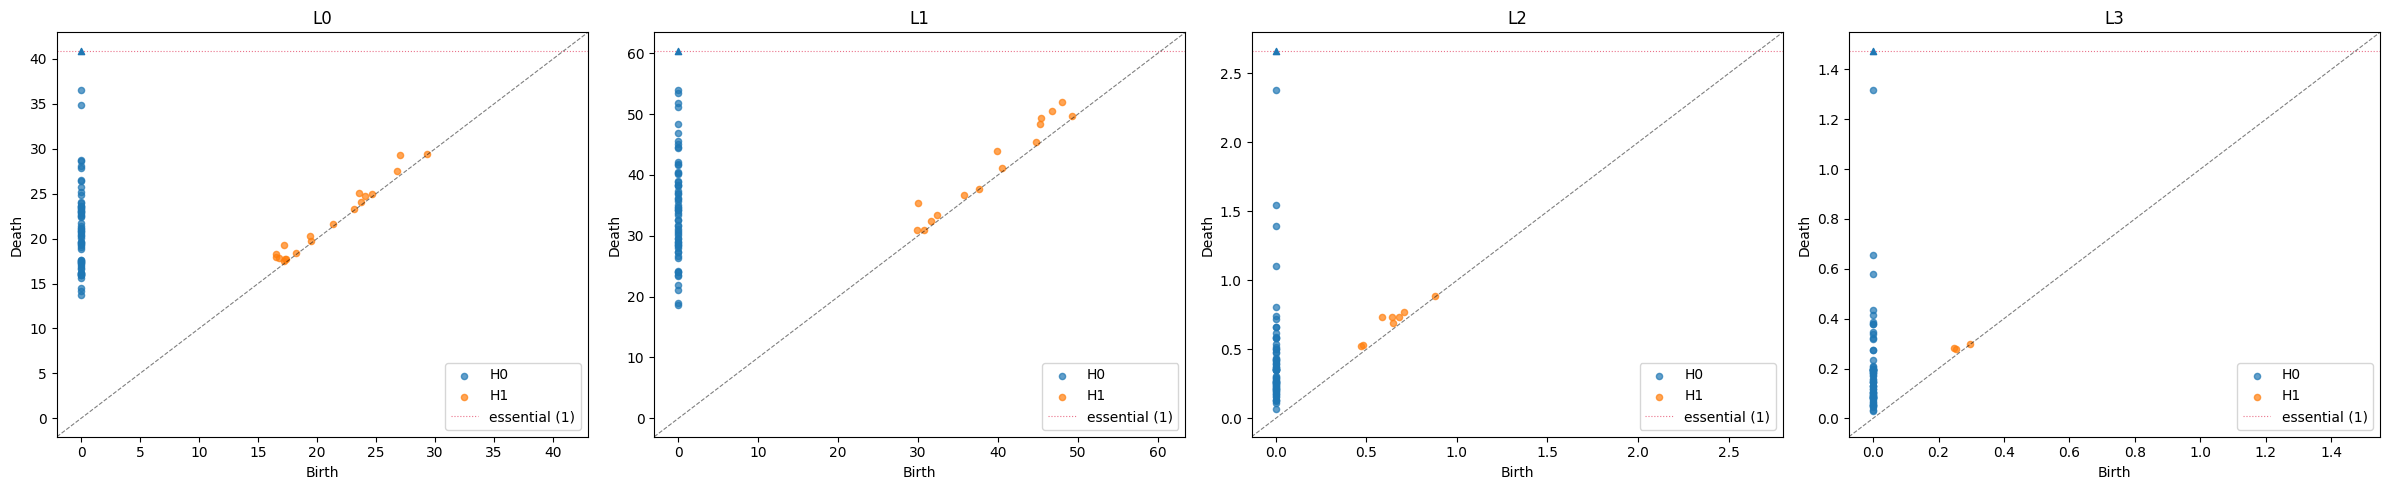

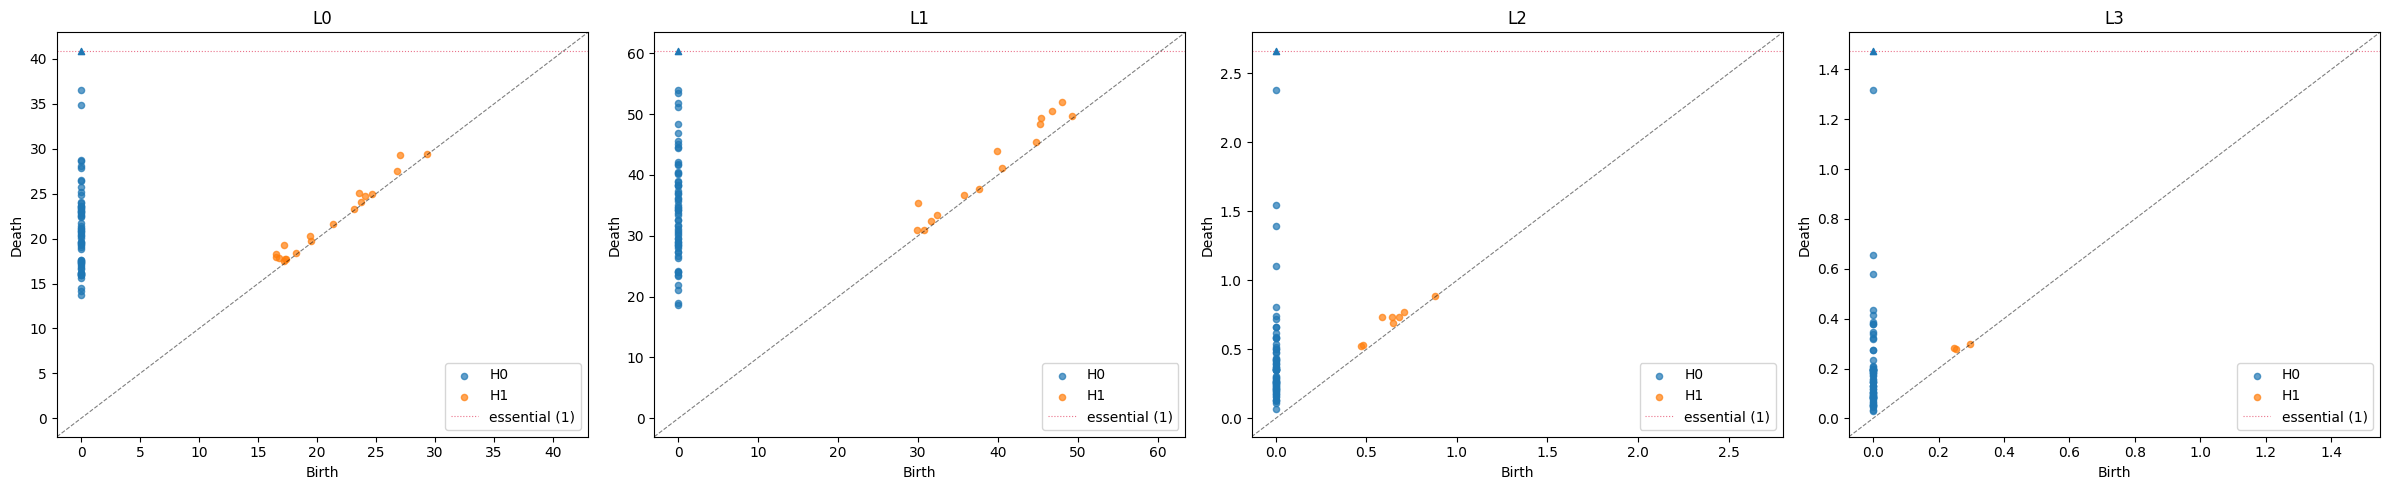

In [5]:
from tanc.visualisation import plot_diagram_comparison
plot_diagram_comparison({f'L{i}': r.ph_result for i, r in enumerate(results)},
                        kind='diagram', dims=[0, 1])


## Notes & gaps

* Implements the method as described, on **real per-layer activations** (model-first via `fit_model`), not synthetic points.
* The paper is methodology-heavy; the depth trend (fewer / shorter-lived H1 generators deeper in the net) is the qualitative result to look for — echoing Naitzat et al. (2020).  Train longer / wider for a cleaner monotonic trend.
* VR PH cost grows with the **sample count** (points in the complex); 64 samples keeps H1 fast.


## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
